In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


In [19]:
df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')# Load your dataset

In [20]:
text_col = "catalog_content"

we take all the numericals feature for training convert all the textual features to numeriacls features 

In [21]:
# 2️⃣ Extract simple numeric features
def make_features(s):
    s = s.fillna("").astype(str)
    return np.vstack([
        s.str.len().values,           # text length
        s.str.split().map(len).values, # word count
        s.str.count(r"\d").values,    # number of digits
        s.str.count(",").values,      # commas
        s.str.count("\.").values      # periods
    ]).T

X_train_features = make_features(df[text_col])
X_test_features = make_features(test_df[text_col])

# Add sample_id as numeric
X_train_features = np.hstack([X_train_features, df["sample_id"].values.reshape(-1, 1)])
X_test_features = np.hstack([X_test_features, test_df["sample_id"].values.reshape(-1, 1)])

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_27117/3604314109.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  s.str.count("\.").values      # periods


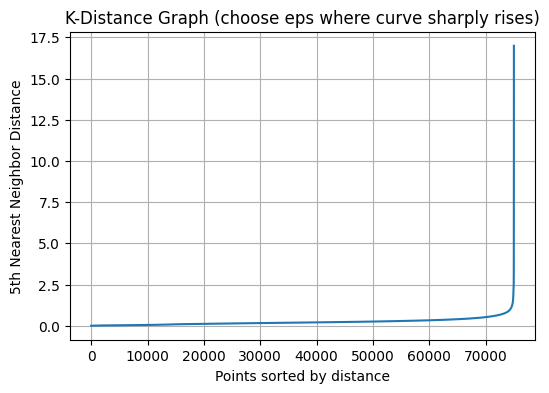

In [22]:
# 3️⃣ Plot k-distance graph (for estimating eps)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train_scaled)
distances, indices = neighbors_fit.kneighbors(X_train_scaled)

# Sort distances
distances = np.sort(distances[:,4])
plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-Distance Graph (choose eps where curve sharply rises)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()


Elbow plot 

In [23]:
# 4️⃣ Train DBSCAN
EPS = 3.0    # 👈 adjust based on elbow plot
MIN_SAMPLES = 10

dbscan = DBSCAN(eps=EPS,min_samples=MIN_SAMPLES)
df["cluster"] = dbscan.fit_predict(X_train_scaled)

# Check cluster counts
print("Cluster distribution:\n", df["cluster"].value_counts())


Cluster distribution:
 cluster
 0    74979
-1       21
Name: count, dtype: int64


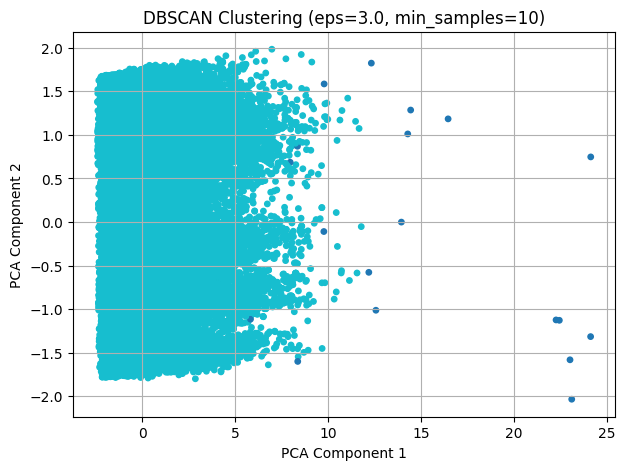

In [24]:
# 5️⃣ Reduce dimensions with PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df["cluster"], cmap='tab10', s=15)
plt.title(f"DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [26]:
# Assign clusters to test data robustly: use centroids when >=2 clusters, else nearest-neighbor fallback
from sklearn.neighbors import NearestCentroid, NearestNeighbors
import numpy as np

# mask of non-noise train rows
valid_mask = df["cluster"] != -1

# if no non-noise points -> mark all test as noise
if valid_mask.sum() == 0:
    print("Warning: DBSCAN found no clusters (all points labeled -1). Assigning -1 to all test samples.")
    test_df["cluster"] = -1
else:
    # select valid train rows and labels
    # ensure boolean mask works with numpy matrix X_train_scaled
    X_valid = X_train_scaled[valid_mask.values] if hasattr(valid_mask, "values") else X_train_scaled[valid_mask]
    labels_valid = df.loc[valid_mask, "cluster"].values
    unique_labels = np.unique(labels_valid)

    if unique_labels.size >= 2:
        # enough classes -> use NearestCentroid (fast & robust)
        centroids = NearestCentroid()
        centroids.fit(X_valid, labels_valid)
        test_clusters = centroids.predict(X_test_scaled)
        test_df["cluster"] = test_clusters
    else:
        # only one valid cluster -> fallback to nearest-neighbor (assign nearest train label)
        print("Only one non-noise cluster present. Falling back to NearestNeighbors assignment.")
        nbrs = NearestNeighbors(n_neighbors=1).fit(X_train_scaled)
        _, indices = nbrs.kneighbors(X_test_scaled)
        test_df["cluster"] = df["cluster"].values[indices.ravel()]


Only one non-noise cluster present. Falling back to NearestNeighbors assignment.


In [ ]:
# 7️⃣ Save clustered data
df.to_csv("train_dbscan_clusters.csv", index=False)
test_df.to_csv("test_dbscan_clusters.csv", index=False)
print("💾 Saved 'train_dbscan_clusters.csv' and 'test_dbscan_clusters.csv'")


💾 Saved 'train_dbscan_clusters.csv' and 'test_dbscan_clusters.csv'
